# Ensembles

Source: [Hyperparameter tuning | Inria Scikit-learn MOOC](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_hyperparameters.html).

We start by loading the california housing dataset.



In [11]:
import pandas as pd

df = pd.read_csv("../../../datasets/california_housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [13]:
# Split X and y
target = df["median_house_value"]
data = df.drop(columns="median_house_value")

In [16]:
# drop the ocean_proximity column since we don't want to encode
# categorical features for now (for simplicity)
data = data.drop(columns="ocean_proximity")

In [17]:
# rescale the target in k$
target *= 100

In [18]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0
)

## Bagging: Random Forest

### `n_estimators`

The main parameter to select in random forest is the `n_estimators` parameter. In general, the more trees in the forest, the better the generalization performance would be. However, adding trees slows down the fitting and prediction time. The goal is to balance computing time and generalization performance when setting the number of estimators. Here, we fix `n_estimators=100`, which is already the default value.

Tuning the `n_estimators` for random forests generally result in a waste of computer power. We just need to ensure that it is large enough so that doubling its value does not lead to a significant improvement of the validation error.

### `max_features`

Instead, we can tune the hyperparameter `max_features`, which controls the size of the random subset of features to consider when looking for the best split when growing the trees: smaller values for `max_features` lead to more random trees with hopefully more uncorrelated prediction errors. However if `max_features` is too small, predictions can be too random, even after averaging with the trees in the ensemble.

If `max_features` is set to `None`, then this is equivalent to setting `max_features=n_features` which means that the only source of randomness in the random forest is the bagging procedure.



### Depth Parameters

We can also tune the different parameters that control the depth of each tree in the forest. Two parameters are important for this: `max_depth` and `max_leaf_nodes`. They differ in the way they control the tree structure.

- Indeed, `max_depth` enforces growing symmetric trees
- while `max_leaf_nodes` does not impose such constraint. If `max_leaf_nodes=None` then the number of leaf nodes is unlimited.

The hyperparameter `min_samples_leaf` controls the minimum number of samples required to be at a leaf node. This means that a split point (at any depth) is only done if it leaves at least `min_samples_leaf` training samples in each of the left and right branches.

- A small value for `min_samples_leaf` means that some samples can become isolated when a tree is deep, promoting overfitting.
- A large value would prevent deep trees, which can lead to underfitting.

Be aware that with random forest:

- trees are expected to be deep since we are seeking to overfit each tree on each bootstrap sample.
- Overfitting is mitigated when combining the trees altogether, whereas assembling underfitted trees (i.e. shallow trees) might also lead to an underfitted forest.

::: {.callout-warning}
For the sake of clarity, no nested cross-validation is used to estimate the variability of the testing error. We are only showing the effect of the parameters on the validation set.
:::

In [37]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_distributions = {
    "max_features": [1, 2, 3, 5, None],
    "max_leaf_nodes": [10, 100, 1000, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
search_cv = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=2),
    param_distributions=param_distributions,
    scoring="neg_mean_absolute_error",
    n_iter=10,
    random_state=0,
    # n_jobs=2,  # Uncomment this line if you run locally
)
search_cv.fit(data_train, target_train)

columns = [f"param_{name}" for name in param_distributions.keys()]
columns += ["mean_test_error", "std_test_error"]
random_forest_cv_results = pd.DataFrame(search_cv.cv_results_)
random_forest_cv_results["mean_test_error"] = -random_forest_cv_results["mean_test_score"]
random_forest_cv_results["std_test_error"] = random_forest_cv_results["std_test_score"]
random_forest_cv_results[columns].sort_values(by="mean_test_error")

,param_max_features,param_max_leaf_nodes,param_min_samples_leaf,mean_test_error,std_test_error
3,2,None,2,3.625294e+08,7.892556e+06
7,None,None,20,3.679168e+08,9.791490e+06
0,2,1000,10,3.948793e+08,7.785347e+06
8,None,100,10,3.963331e+08,9.128579e+06
4,5,100,2,4.020017e+08,7.348916e+06
6,None,1000,50,4.092896e+08,9.048346e+06
9,1,100,2,5.388507e+08,9.480600e+06
2,1,100,1,5.406847e+08,1.104324e+07
1,3,10,10,5.724519e+08,7.179942e+06
5,1,None,100,5.837197e+08,5.423958e+06


We can visualize the HP choices with the test score in a figure with 3 heatmaps:

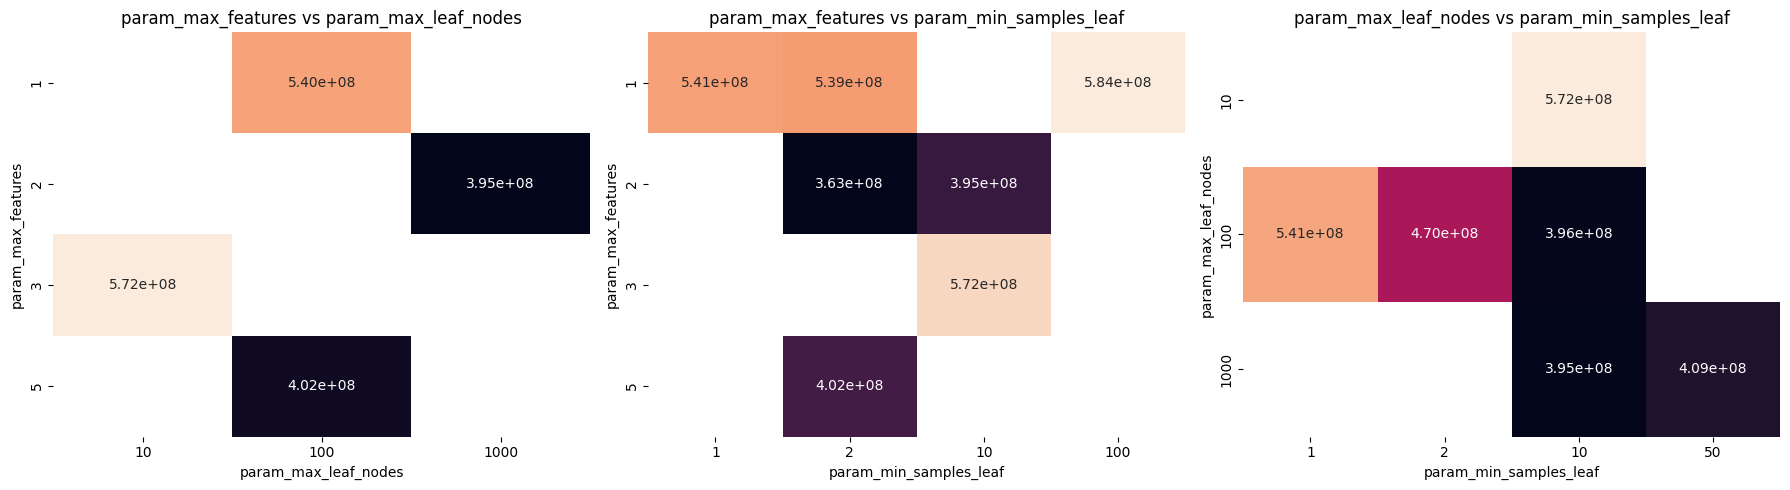

In [40]:
#|code-fold: true

import matplotlib.pyplot as plt
import seaborn as sns

def plot_param_heatmap(ax, x_param, y_param, title):
    # To avoid error: "Index contains duplicate entries, cannot reshape",
    # group by the parameter combinations, aggregate (mean), and then pivot
    grouped = random_forest_cv_results.groupby([x_param, y_param])["mean_test_error"].mean().reset_index()
    pivot_df = grouped.pivot(index=x_param, columns=y_param, values="mean_test_error")
    sns.heatmap(
        pivot_df,
        ax=ax,
        vmin=grouped['mean_test_error'].min(),  # adapt vmin/vmax for range
        vmax=grouped['mean_test_error'].max(),
        annot=True,
        fmt=".2e",
        cbar=False,
    )
    ax.set_title(title)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

plot_param_heatmap(
    axs.flat[0],
    "param_max_features",
    "param_max_leaf_nodes",
    "param_max_features vs param_max_leaf_nodes"
)

plot_param_heatmap(
    axs.flat[1],
    "param_max_features",
    "param_min_samples_leaf",
    "param_max_features vs param_min_samples_leaf"
)

plot_param_heatmap(
    axs.flat[2],
    "param_max_leaf_nodes",
    "param_min_samples_leaf",
    "param_max_leaf_nodes vs param_min_samples_leaf"
)

plt.tight_layout()
plt.show()

We can observe in our search that we are required to have a large number of `max_leaf_nodes` and thus deep trees. This parameter seems particularly impactful with respect to the other tuning parameters, but large values of `min_samples_leaf` seem to reduce the performance of the model.

In practice, more iterations of random search would be necessary to precisely assert the role of each parameters. Using `n_iter=10` is good enough to quickly inspect the hyperparameter combinations that yield models that work well enough without spending too much computational resources. Feel free to try more interations on your own.

Once the `RandomizedSearchCV` has found the best set of hyperparameters, it uses them to refit the model using the full training set. To estimate the generalization performance of the best model it suffices to call `.score` on the unseen data.

In [ ]:
error = -search_cv.score(data_test, target_test)
print(
    f"On average, our random forest regressor makes an error of {error:.2f} k$"
)

## Boosting: Histogram gradient-boosting decision trees

For gradient-boosting, hyperparameters are coupled, so we cannot set them one after the other anymore. The important hyperparameters are `max_iter`, `learning_rate`, and `max_depth` or `max_leaf_nodes` (as previously discussed random forest).

Let’s first discuss `max_iter` which, similarly to the `n_estimators` hyperparameter in random forests, controls the number of trees in the estimator. The difference is that the actual number of trees trained by the model is not entirely set by the user, but depends also on the stopping criteria: the number of trees can be lower than `max_iter` if adding a new tree does not improve the model enough. We will give more details on this in the next exercise.

The depth of the trees is controlled by `max_depth` (or `max_leaf_nodes`). We saw in the section on gradient-boosting that boosting algorithms fit the error of the previous tree in the ensemble. Thus, fitting fully grown trees would be detrimental. Indeed, the first tree of the ensemble would perfectly fit (overfit) the data and thus no subsequent tree would be required, since there would be no residuals. Therefore, the tree used in gradient-boosting should have a low depth, typically between 3 to 8 levels, or few leaves ( to ). Having very weak learners at each step helps reducing overfitting.

With this consideration in mind, the deeper the trees, the faster the residuals are corrected and then less learners are required. Therefore, it can be beneficial to increase `max_iter` if `max_depth` is low.

### `learning_rate`

Finally, we have overlooked the impact of the `learning_rate` parameter until now. This parameter controls how much each correction contributes to the final prediction. A smaller learning-rate means the corrections of a new tree result in small adjustments to the model prediction. When the learning-rate is small, the model generally needs more trees to achieve good performance. A higher learning-rate makes larger adjustments with each tree, which requires fewer trees and trains faster, at the risk of overfitting. The learning-rate needs to be tuned by hyperparameter tuning to obtain the best value that results in a model with good generalization performance.

In [42]:
from scipy.stats import loguniform
from sklearn.ensemble import HistGradientBoostingRegressor

param_distributions = {
    "max_iter": [3, 10, 30, 100, 300, 1000],
    "max_leaf_nodes": [2, 5, 10, 20, 50, 100],
    "learning_rate": loguniform(0.01, 1),
}
search_cv = RandomizedSearchCV(
    HistGradientBoostingRegressor(),
    param_distributions=param_distributions,
    scoring="neg_mean_absolute_error",
    n_iter=20,
    random_state=0,
    # n_jobs=2, # Uncomment this line if you run locally
)
search_cv.fit(data_train, target_train)

columns = [f"param_{name}" for name in param_distributions.keys()]
columns += ["mean_test_error", "std_test_error"]
HGBT_cv_results = pd.DataFrame(search_cv.cv_results_)
HGBT_cv_results["mean_test_error"] = -HGBT_cv_results["mean_test_score"]
HGBT_cv_results["std_test_error"] = HGBT_cv_results["std_test_score"]
HGBT_cv_results[columns].sort_values(by="mean_test_error")

,param_max_iter,param_max_leaf_nodes,param_learning_rate,mean_test_error,std_test_error
14,300,100,0.018640,3.163381e+08,5.277205e+06
6,300,20,0.047293,3.258230e+08,5.255011e+06
13,300,10,0.297739,3.289307e+08,7.509547e+06
2,30,50,0.176656,3.317382e+08,6.155790e+06
9,100,20,0.083745,3.378613e+08,4.944780e+06
19,100,10,0.215543,3.411934e+08,5.593975e+06
12,100,20,0.067503,3.443942e+08,4.801037e+06
16,300,5,0.059290,3.697084e+08,7.995516e+06
1,100,5,0.160519,3.759628e+08,5.625948e+06
0,1000,2,0.125207,4.250929e+08,7.468701e+06


::: {.callout-warning}
Here, we tune `max_iter` but be aware that it is better to set `max_iter` to a fixed, large enough value and use parameters linked to `early_stopping` as we will do in Exercise M6.04.
:::

In this search, we observe that for the best ranked models, having a smaller `learning_rate`, requires more trees or a larger number of leaves for each tree. However, it is particularly difficult to draw more detailed conclusions since the best value of each hyperparameter depends on the other hyperparameter values.

We can now estimate the generalization performance of the best model using the test set.

In [47]:
error = -search_cv.score(data_test, target_test)
print(f"On average, our HGBT regressor makes an error of {error:.2f} k$")

On average, our HGBT regressor makes an error of 314097084.82 k$


The mean test score in the held-out test set is slightly better than the score of the best model. The reason is that the final model is refitted on the whole training set and therefore, on more data than the cross-validated models of the grid search procedure.

We summarize these details in the following table:

|**Bagging & Random Forests**|**Boosting**|
|---|---|
|fit trees **independently**|fit trees **sequentially**|
|each **deep tree overfits**|each **shallow tree underfits**|
|averaging the tree predictions **reduces overfitting**|sequentially adding trees **reduces underfitting**|
|generalization improves with the number of trees|too many trees may cause overfitting|
|does not have a `learning_rate` parameter|fitting the residuals is controlled by the `learning_rate`|